In [1]:
import pandas as pd

In [2]:
print(pd.__version__)

3.0.5


In [3]:
# Imported the dataset into a pandas dataframe.
df = pd.read_csv('../data/Nassau Candy Distributor.csv')

In [4]:
df.head()     # visual preview of the first 5 rows of the dataset.

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
print(df.shape)    # prints the number of rows and columns in the dataset.

(10194, 18)


In [6]:
df.dtypes    # prints the data types of each column in the dataset.

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [7]:
df.info()      # prints a concise summary of the dataframe, including the number of non-null values and memory usage.

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [8]:
df['Order Date'].head()

0    03-01-2024
1    04-01-2024
2    04-01-2024
3    04-01-2024
4    05-01-2024
Name: Order Date, dtype: str

In [9]:
df['Ship Date'].head()

0    30-06-2026
1    01-07-2026
2    01-07-2026
3    01-07-2026
4    05-07-2026
Name: Ship Date, dtype: str

In [10]:
df.duplicated().sum()     # prints the number of duplicate rows in the dataset.

np.int64(0)

In [11]:
df['Row ID'].duplicated().sum()     # prints the number of duplicate values in the 'Row ID' column.         

np.int64(0)

In [12]:
df['Division'].value_counts()     # prints the count of unique values in the 'Division' column.

Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

In [13]:
df['Region'].value_counts()

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

In [14]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

In [15]:
df[['Sales', 'Units', 'Gross Profit', 'Cost']].describe()

,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087
std,11.341020,2.228317,6.643740,5.061647
min,1.250000,1.000000,0.250000,0.600000
25%,7.200000,2.000000,4.900000,2.400000
50%,10.800000,3.000000,7.470000,3.600000
75%,18.000000,5.000000,12.250000,5.700000
max,260.000000,14.000000,130.000000,130.000000


In [16]:
(df['Cost'] > df['Sales']).sum()     # prints the number of rows where the 'Cost' is greater than 'Sales'.  

np.int64(0)

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Order Date'].dtype

dtype('<M8[us]')

In [18]:
df['Ship Date'] = pd.DataFrame(pd.to_datetime(df['Ship Date'], format='%d-%m-%Y'))
df['Ship Date'].dtype

dtype('<M8[us]')

In [19]:
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2024-01-02 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

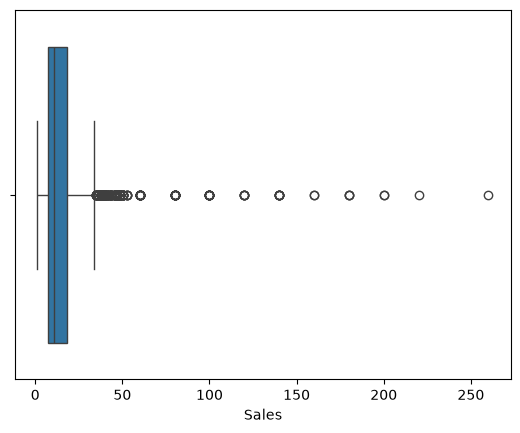

In [21]:
# Boxplot
sns.boxplot(x=df['Sales'])
plt.show()

In [22]:
df.nlargest(10, 'Sales')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
365,366,US-2021-122336-OTH-LIC-15000,2024-04-13,2026-10-08,Second Class,122336,United States,Philadelphia,Pennsylvania,19140,Other,Atlantic,OTH-LIC-15000,Lickable Wallpaper,260.0,13,130.0,130.0
5827,5828,US-2023-124163-OTH-LIC-15000,2025-09-25,2029-03-22,Standard Class,124163,United States,La Crosse,Wisconsin,54601,Other,Interior,OTH-LIC-15000,Lickable Wallpaper,220.0,11,110.0,110.0
4831,4832,US-2023-107202-OTH-LIC-15000,2025-05-21,2028-11-17,Standard Class,107202,United States,Sparks,Nevada,89431,Other,Pacific,OTH-LIC-15000,Lickable Wallpaper,200.0,10,100.0,100.0
6472,6473,US-2023-164770-OTH-LIC-15000,2025-12-02,2029-05-26,Second Class,164770,United States,Houston,Texas,77036,Other,Interior,OTH-LIC-15000,Lickable Wallpaper,200.0,10,100.0,100.0
1208,1209,US-2021-147900-OTH-LIC-15000,2024-09-23,2027-03-21,Standard Class,147900,United States,Lakewood,Ohio,44107,Other,Atlantic,OTH-LIC-15000,Lickable Wallpaper,180.0,9,90.0,90.0
6980,6981,US-2024-164147-OTH-LIC-15000,2025-02-02,2029-07-28,First Class,164147,United States,Columbus,Ohio,43229,Other,Atlantic,OTH-LIC-15000,Lickable Wallpaper,180.0,9,90.0,90.0
8534,8535,US-2024-140326-OTH-LIC-15000,2025-09-04,2030-02-27,First Class,140326,United States,Chicago,Illinois,60653,Other,Interior,OTH-LIC-15000,Lickable Wallpaper,180.0,9,90.0,90.0
1789,1790,US-2021-106376-OTH-LIC-15000,2024-12-05,2027-06-02,Standard Class,106376,United States,Gilbert,Arizona,85234,Other,Pacific,OTH-LIC-15000,Lickable Wallpaper,160.0,8,80.0,80.0
5206,5207,US-2023-136924-OTH-LIC-15000,2025-07-14,2029-01-06,First Class,136924,United States,Tucson,Arizona,85705,Other,Pacific,OTH-LIC-15000,Lickable Wallpaper,160.0,8,80.0,80.0
1156,1157,US-2021-106992-OTH-LIC-15000,2024-09-19,2027-03-14,Second Class,106992,United States,Houston,Texas,77036,Other,Interior,OTH-LIC-15000,Lickable Wallpaper,140.0,7,70.0,70.0


In [23]:
df.nlargest(10, 'Sales')[['Sales', 'Units', 'Cost', 'Gross Profit']]

,Sales,Units,Cost,Gross Profit
365,260.0,13,130.0,130.0
5827,220.0,11,110.0,110.0
4831,200.0,10,100.0,100.0
6472,200.0,10,100.0,100.0
1208,180.0,9,90.0,90.0
6980,180.0,9,90.0,90.0
8534,180.0,9,90.0,90.0
1789,160.0,8,80.0,80.0
5206,160.0,8,80.0,80.0
1156,140.0,7,70.0,70.0


In [24]:
(df['Sales'] == 2 * df['Cost']).sum()     # this counts how many of all 10,194 rows exactly satisfy that 2x relationship between 'Sales' and 'Cost'.

np.int64(94)

In [25]:
df['temp_margin'] = df['Gross Profit'] / df['Sales']
df['temp_margin'].describe()

count    10194.000000
mean         0.665140
std          0.067210
min          0.076923
25%          0.653333
50%          0.666667
75%          0.694444
max          0.800000
Name: temp_margin, dtype: float64

In [26]:
df = df.drop(columns=['temp_margin'])          # drops the temp_margin column from the dataset.

In [27]:
df.to_csv('../data/cleaned_data.csv', index=False)

#### Load the cleaned data fresh

In [28]:
df = pd.read_csv('../data/cleaned_data.csv')

#### Reconvert the date columns to datetime datatype

In [29]:
df['Order Date'].dtype

<StringDtype(na_value=nan)>

In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')
df['Order Date'].dtype

dtype('<M8[us]')

In [31]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%Y-%m-%d')
df['Ship Date'].dtype

dtype('<M8[us]')

##### KPI1: Gross Margin (%)
* Formula :- Gross Profit % Sales

In [32]:
df['Gross Margin'] = df['Gross Profit'] / df['Sales']
df['Gross Margin'].describe()

count    10194.000000
mean         0.665140
std          0.067210
min          0.076923
25%          0.653333
50%          0.666667
75%          0.694444
max          0.800000
Name: Gross Margin, dtype: float64

##### KPI2: Profit per Unit
* Formula :- Gross Profit % Units  

In [33]:
df['Profit per Unit'] = df['Gross Profit'] / df['Units']
df['Profit per Unit'].describe()

count    10194.000000
mean         2.412539
std          0.806007
min          0.250000
25%          2.400000
50%          2.450000
75%          2.490000
max         10.000000
Name: Profit per Unit, dtype: float64

In [34]:
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
print(total_sales)
print(total_profit)

141783.63
93442.79999999999


##### KPI3: Revenue Contribution
* Formula :- Product sales % total sales 

In [35]:
df['Revenue Contribution'] = df['Sales'] / total_sales
df['Revenue Contribution'].sum()

np.float64(0.9999999999999999)

##### KPI3: Profit Contribution 
* Formula :- Product Profit % total profit

In [36]:
df['Profit Contribution'] = df['Gross Profit'] / total_profit
df['Profit Contribution'].sum()

np.float64(1.0000000000000002)

##### KPI5: Margin Volatility (variability of margin over time)

In [37]:
df['Order Date'].value_counts()         # prints  

Order Date
2025-09-02    62
2025-12-01    57
2025-12-02    57
2025-12-09    54
2025-11-24    52
              ..
2024-04-14     1
2024-04-24     1
2025-10-18     1
2025-10-25     1
2025-01-06     1
Name: count, Length: 717, dtype: int64

In [38]:
# Step1 : Extract the month from Order Date
df['Order Month'] = df['Order Date'].dt.to_period('M')

In [39]:
# Step2 : Group by month and calculates average margin per month
monthly_margin = df.groupby('Order Month')['Gross Margin'].mean()
print(monthly_margin)

Order Month
2024-01    0.659199
2024-02    0.662564
2024-03    0.655998
2024-04    0.667433
2024-05    0.663441
2024-06    0.663179
2024-07    0.662954
2024-08    0.664027
2024-09    0.667829
2024-10    0.662733
2024-11    0.663154
2024-12    0.666035
2025-01    0.663769
2025-02    0.672426
2025-03    0.666661
2025-04    0.664252
2025-05    0.666408
2025-06    0.667298
2025-07    0.663339
2025-08    0.664158
2025-09    0.669236
2025-10    0.666112
2025-11    0.665312
2025-12    0.664506
Freq: M, Name: Gross Margin, dtype: float64


In [40]:
# Calculate standard deviation as margin volatility
margin_volatility = monthly_margin.std()
print(f"Margin Volatility (monthly std dev): {margin_volatility:.4f}")

Margin Volatility (monthly std dev): 0.0032


In [41]:
# Save your dataset with calculated KPIs
df.to_csv('../data/kpi_data.csv', index=False)

##### Load KPI based dataset

In [42]:
df = pd.read_csv('../data/kpi_data.csv')

In [43]:
product_summary = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross Margin': 'mean',
    'Units': 'sum'
})
print(product_summary)

                                      Sales  Gross Profit  Gross Margin  Units
Product Name                                                                  
Everlasting Gobstopper               130.00        104.00      0.800000     13
Fizzy Lifting Drinks                  78.75         47.25      0.600000     21
Fun Dip                               12.00          4.80      0.400000      8
Hair Toffee                           76.50         59.50      0.777778     17
Kazookles                           1205.75         92.75      0.076923    371
Laffy Taffy                           53.73         33.48      0.623116     27
Lickable Wallpaper                  7860.00       3930.00      0.500000    393
Nerds                                 15.00          7.00      0.466667     10
SweeTARTS                             61.50         28.70      0.466667     41
Wonka Bar - Fudge Mallows          24890.40      16593.60      0.666667   6914
Wonka Bar - Milk Chocolate         26867.75      174

In [44]:
product_summary.sort_values('Gross Profit', ascending=False)

,Sales,Gross Profit,Gross Margin,Units
Product Name,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,0.694444,7743
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,0.653333,7596
Wonka Bar - Milk Chocolate,26867.75,17443.37,0.649231,8267
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,0.713467,6755
Wonka Bar - Fudge Mallows,24890.40,16593.60,0.666667,6914
Lickable Wallpaper,7860.00,3930.00,0.500000,393
Wonka Gum,597.50,310.70,0.520000,478
Everlasting Gobstopper,130.00,104.00,0.800000,13
Kazookles,1205.75,92.75,0.076923,371


In [45]:
product_summary.sort_values('Gross Margin', ascending=False)

,Sales,Gross Profit,Gross Margin,Units
Product Name,,,,
Everlasting Gobstopper,130.00,104.00,0.800000,13
Hair Toffee,76.50,59.50,0.777778,17
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,0.713467,6755
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,0.694444,7743
Wonka Bar - Fudge Mallows,24890.40,16593.60,0.666667,6914
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,0.653333,7596
Wonka Bar - Milk Chocolate,26867.75,17443.37,0.649231,8267
Laffy Taffy,53.73,33.48,0.623116,27
Fizzy Lifting Drinks,78.75,47.25,0.600000,21


In [46]:
product_summary.sort_values('Gross Margin')

,Sales,Gross Profit,Gross Margin,Units
Product Name,,,,
Kazookles,1205.75,92.75,0.076923,371
Fun Dip,12.00,4.80,0.400000,8
Nerds,15.00,7.00,0.466667,10
SweeTARTS,61.50,28.70,0.466667,41
Lickable Wallpaper,7860.00,3930.00,0.500000,393
Wonka Gum,597.50,310.70,0.520000,478
Fizzy Lifting Drinks,78.75,47.25,0.600000,21
Laffy Taffy,53.73,33.48,0.623116,27
Wonka Bar - Milk Chocolate,26867.75,17443.37,0.649231,8267


In [47]:
product_summary = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross Margin': 'mean'
})
print(product_summary)

               Sales  Gross Profit  Gross Margin
Division                                        
Chocolate  131692.90      88824.62      0.674582
Other        9663.25       4333.45      0.376725
Sugar         427.48        284.73      0.576890


##### Pareto (80/20) Analysis

* Purpose : Determine what percentage of products account for 80% of total Gross Profit.

    Measures how concentrated (or diversified) the business's profit is across its product portfolio.
    
    High concentration means heavy dependence on a small number of products (risk); low concentration means profit is spread more evenly.

* Method : Sort products by Gross Profit (descending), calculate a running cumulative total, convert to cumulative percentage of overall total.

    The point where cumulative % crosses 80% tells us how many top products are responsible for 80% of profit.

In [48]:
product_summary_by_product = df.groupby('Product Name').agg({
    'Sales' : 'sum',
    'Cost' : 'sum',
    'Gross Profit' : 'sum',
    'Gross Margin' : 'mean',
    'Units' : 'sum'
})

In [49]:
pareto = product_summary_by_product.sort_values('Gross Profit', ascending=False)


In [50]:
pareto['Cumulative Profit'] = pareto['Gross Profit'].cumsum()

In [51]:
pareto['Cumulative Profit %'] = (pareto['Cumulative Profit'] / pareto['Gross Profit'].sum()) * 100

In [52]:
print(pareto[['Gross Profit', 'Cumulative Profit %']])

                                   Gross Profit  Cumulative Profit %
Product Name                                                        
Wonka Bar -Scrumdiddlyumptious         19357.50            20.715882
Wonka Bar - Triple Dazzle Caramel      18610.20            40.632023
Wonka Bar - Milk Chocolate             17443.37            59.299454
Wonka Bar - Nutty Crunch Surprise      16819.95            77.299717
Wonka Bar - Fudge Mallows              16593.60            95.057747
Lickable Wallpaper                      3930.00            99.263528
Wonka Gum                                310.70            99.596031
Everlasting Gobstopper                   104.00            99.707329
Kazookles                                 92.75            99.806588
Hair Toffee                               59.50            99.870263
Fizzy Lifting Drinks                      47.25            99.920829
Laffy Taffy                               33.48            99.956658
SweeTARTS                         

### Cost vs Sales --> Product-Level Scatter Plot

In [53]:
product_summary_by_product.columns

Index(['Sales', 'Cost', 'Gross Profit', 'Gross Margin', 'Units'], dtype='str')

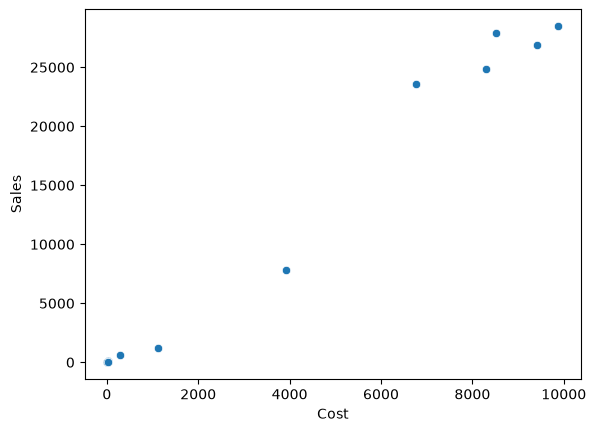

In [54]:
sns.scatterplot(data=product_summary_by_product, x='Cost', y='Sales')
plt.show()

In [55]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')

count = df[(df['Order Date'] >= '2024-02-01') & (df['Order Date'] <= '2024-03-31')].shape[0]
print(count)

410


In [56]:
df.groupby(df['Order Date'].dt.to_period('M')).size()

Order Date
2024-01    148
2024-02    110
2024-03    300
2024-04    295
2024-05    282
2024-06    274
2024-07    283
2024-08    320
2024-09    568
2024-10    335
2024-11    644
2024-12    622
2025-01    256
2025-02    190
2025-03    411
2025-04    375
2025-05    476
2025-06    451
2025-07    435
2025-08    402
2025-09    831
2025-10    508
2025-11    830
2025-12    848
Freq: M, dtype: int64